In [16]:
!which python

/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/bin/python


In [51]:
#If there are issues with importing modules. This is for reloading a module
import importlib
import computations_funcs
module=computations_funcs
importlib.reload(module)

<module 'computations_funcs' from '/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/computations_funcs.py'>

In [52]:
import ee
from dotenv import load_dotenv
import os
from data_collection import get_state_districs,get_region_for_districts,generate_mask_for_region,get_data_for_districts
import numpy as np
import matplotlib.pyplot as plt
from computations_funcs import smooth_stack_from_array_dict , resize_img ,generate_probability_mask
from data_initialization import categorical_labels,band_cmaps,mcdm_weights
from plot_funcs import plot_bands_one_by_one
import matplotlib.colors as mcolors



load_dotenv()

PROJECT_NAME = os.getenv("PROJECT_NAME")
if PROJECT_NAME is None:
    raise Exception("Please set the PROJECT_NAME environment variable")

In [2]:
print('Initializing Earth Engine')
try:
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
except Exception as e:
    print('Initializing Earth Engine for the first time')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
# NOTE: This is a test to check if ee is initialized
# image = ee.Image('USGS/SRTMGL1_003')
# print(image.getInfo())

Initializing Earth Engine
Successfully initialized Earth Engine Project be-project-aaronfurtado2003


In [4]:
state=''
while(state==''):
    state=input("Please Enter a state name:")

state_source,districts=get_state_districs(state)
print(f'List of Districts in {state} are:\n{districts}')
print('\n')
selected_districts_unfiltered=input("Please Enter the name of the Districts separated by comma:\n")
selected_districts=selected_districts_unfiltered.split(',')
selected_districts=[district.strip() for district in selected_districts]

print(f'Selected Districts are:\n{selected_districts}')

List of Districts in West Bengal are:
['Dakshin Dinajpur', 'Uttar Dinajpur', 'West Midnapore', 'Bankura', 'Barddhaman', 'Birbhum', 'Darjiling', 'Haora', 'Hugli', 'Jalpaiguri', 'Kochbihar', 'Maldah', 'Murshidabad', 'Nadia', 'Puruliya', 'Kolkata', 'North 24 Parganas', 'South 24 Parganas', 'East Midnapore']


Selected Districts are:
['Puruliya']


In [5]:
print(f'Collecting data for {selected_districts}')
print(f'Getting region scale and boundary for districts')
region,scale,region_self_mask=get_region_for_districts(state_source,selected_districts)

print(f'Generating masks for selected region')
mask_projection,region_mask=generate_mask_for_region(region,scale)

print(f'Collecting data for {selected_districts}')
array_dict=get_data_for_districts(region,scale,mask_projection,region_self_mask)

Getting region scale and boundary for districts
Generating masks for selected region


/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3.13/site-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3.13/site-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2

  warnings.warn(warning, category=DeprecationWarning)
/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3.13/site-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for NASA_USDA/HSL/SMAP10KM_soil_moisture! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/NASA_USDA_HSL_SMAP10KM_soil_moisture

  warnings.warn(warning, category=DeprecationWarning)


In [28]:
print(f'Resizing and smoothing collected data')
smoothed_stack,band_names=smooth_stack_from_array_dict(array_dict,categorical_bands=categorical_labels.keys())
print(f'Stack shape: {smoothed_stack.shape}')
print(f'Band names: {band_names}')

Resizing and smoothing collected data
Stack shape: (516, 512, 11)
Band names: ['dist_to_water', 'flow_acc', 'geom', 'lulc', 'ndwi', 'rain', 'runoff_coeff', 'slope', 'soilTx', 'soil_moisture', 'stream_order']


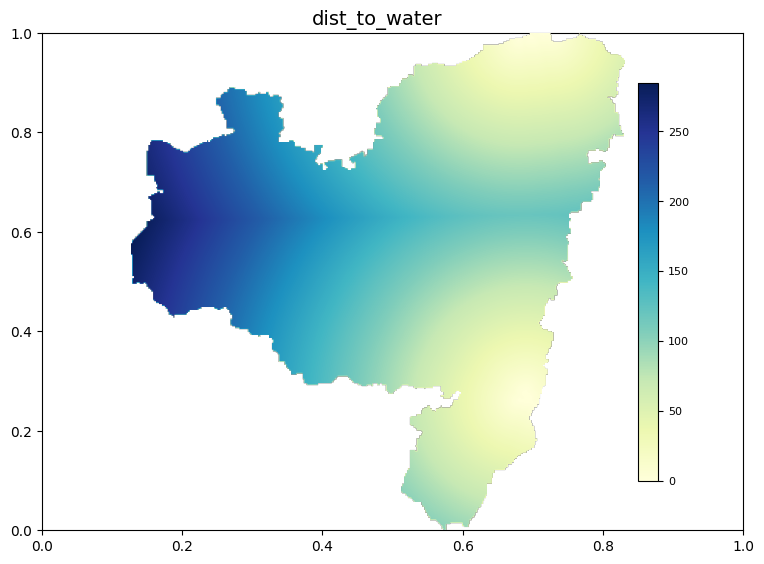

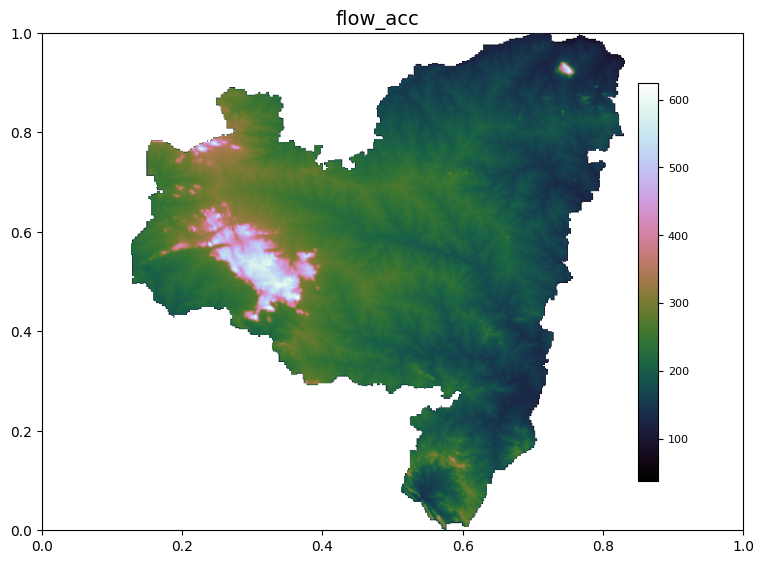

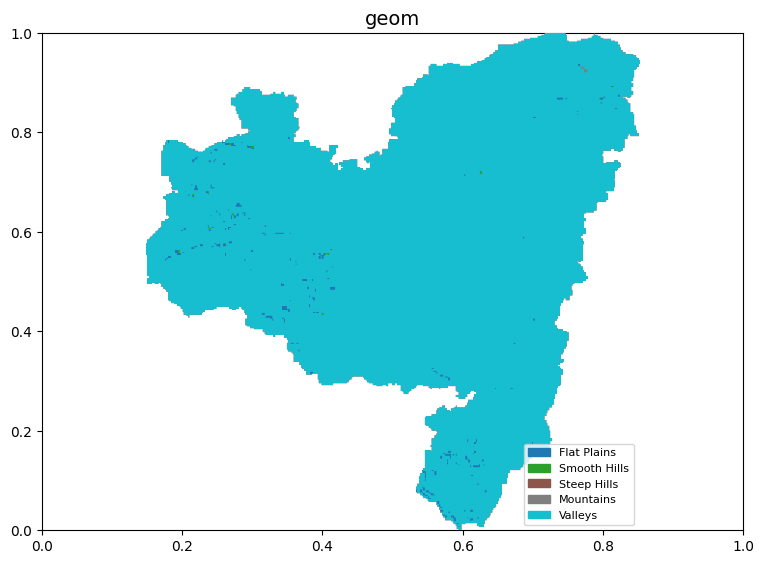

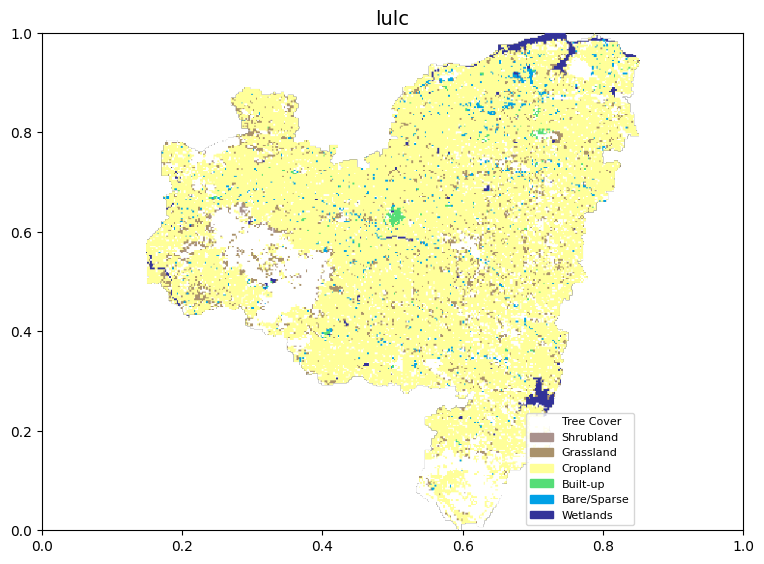

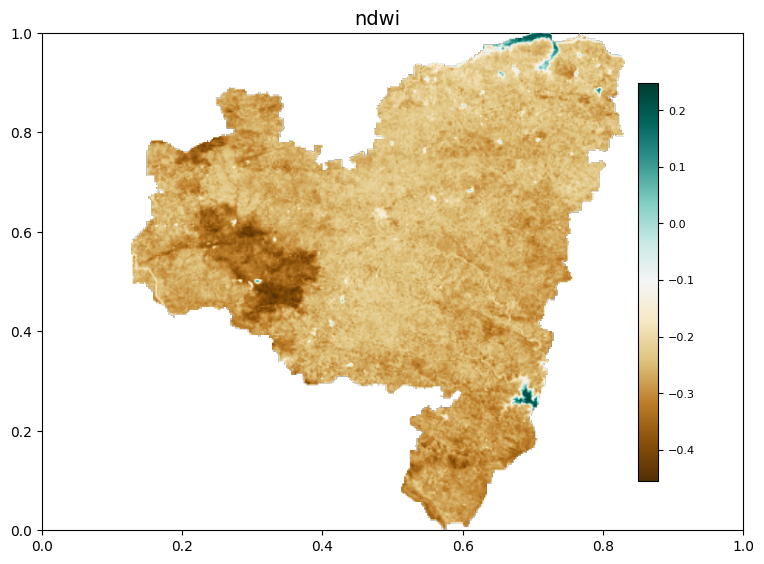

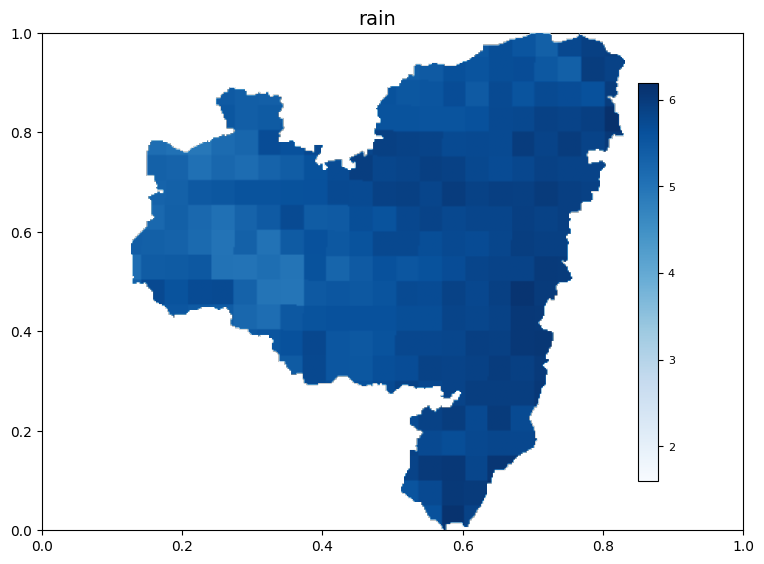

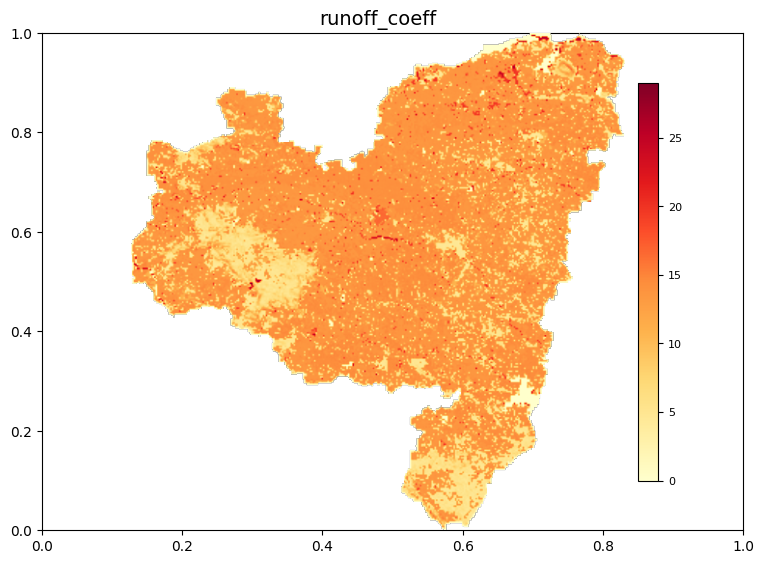

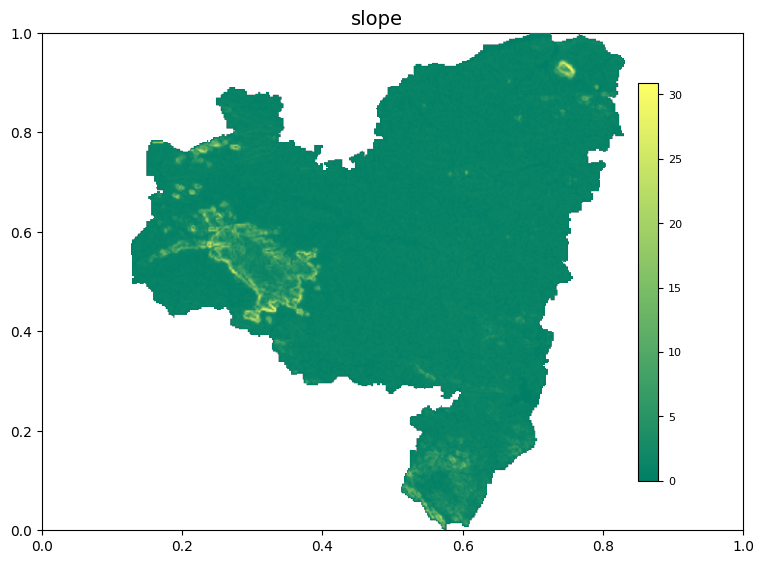

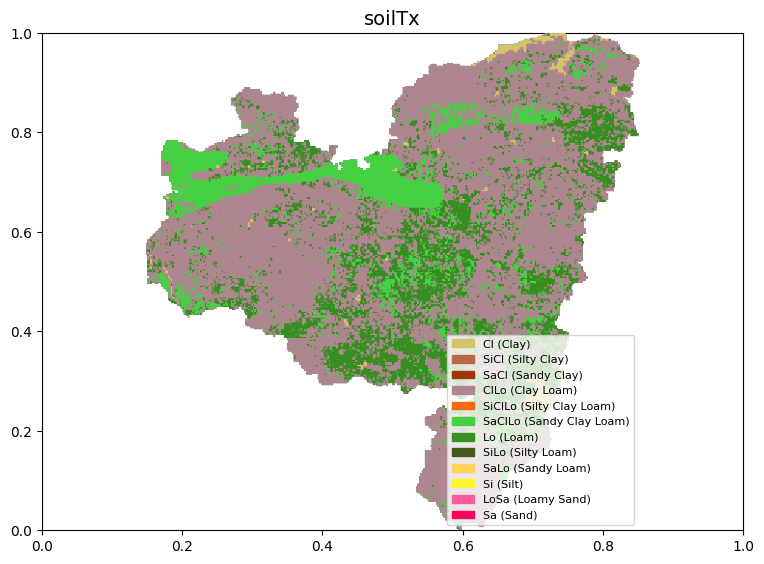

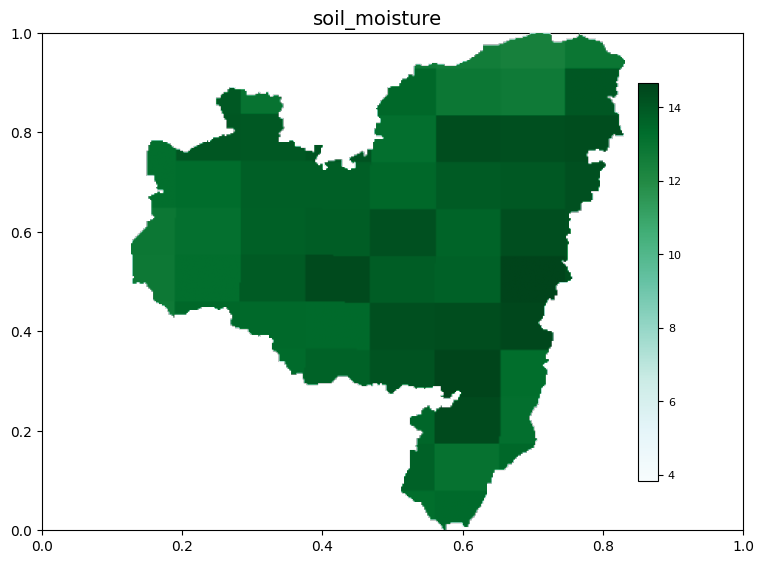

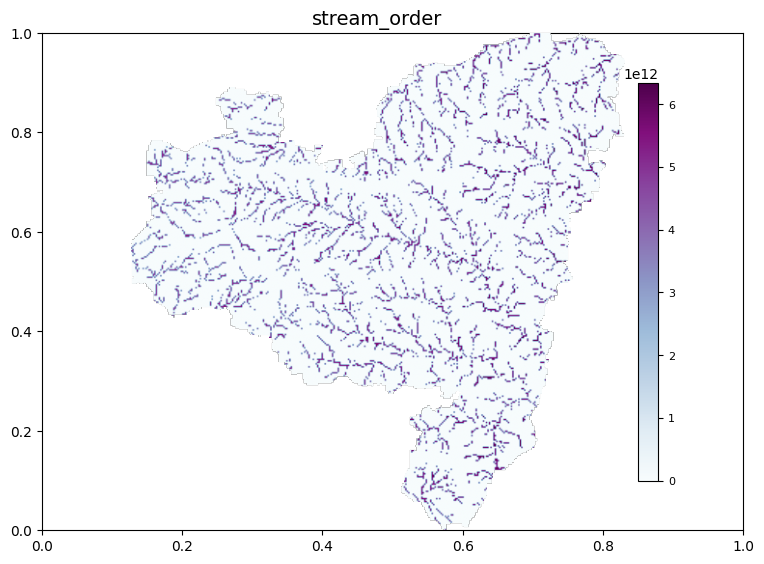

In [29]:
plot_choice=''
while(plot_choice.lower() not in ['y','n']):
    plot_choice=input("Do you want to plot the data? (y/n):")
    if plot_choice.lower()=='y':
        plot_bands_one_by_one(stacked_array=smoothed_stack,band_names=band_names,region_mask=resize_img(region_mask),band_cmaps=band_cmaps,categorical_labels=categorical_labels)
    else:
        print('No problem!')

In [35]:
smoothed_stack[:,:,0]
band_names[0]

'dist_to_water'

stacked shape: (516, 512, 11)
wts shape: (11,)


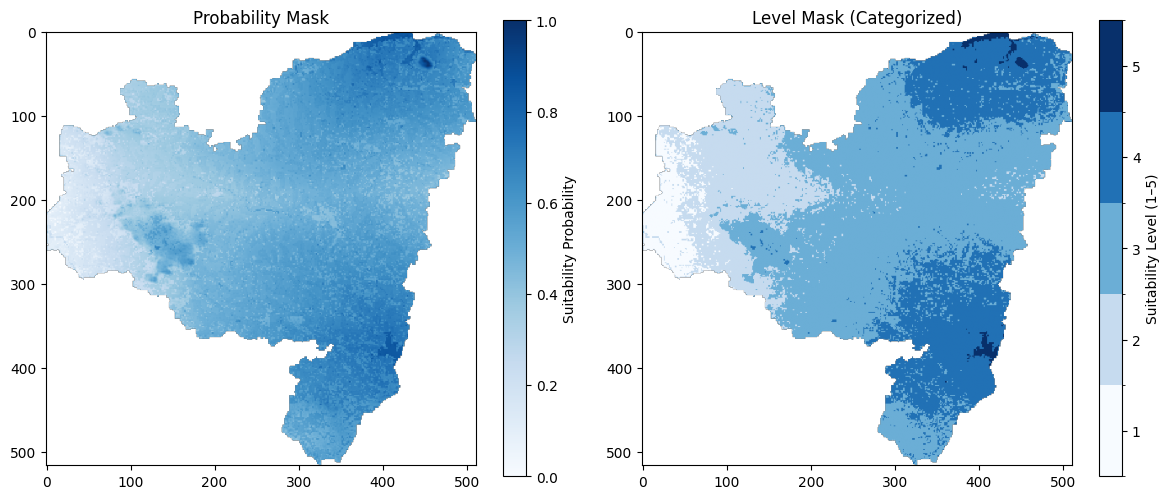

In [54]:
prob_mask, level_mask, weighted_sum  = generate_probability_mask(smoothed_stack=smoothed_stack,band_names=band_names,weights=mcdm_weights)
masked_prob = (np.where(resize_img(region_mask) == 1, prob_mask, np.nan))
masked_level =( np.where(resize_img(region_mask) == 1, level_mask, np.nan))
plt.figure(figsize=(12, 5))

# Plot probability mask
plt.subplot(1, 2, 1)
plt.imshow(masked_prob, cmap='Blues')
plt.colorbar(label='Suitability Probability')
plt.title('Probability Mask')

# Plot level mask
plt.subplot(1, 2, 2)
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], ncolors=5)
im = plt.imshow(masked_level, plt.get_cmap('Blues', 5), norm=norm)
cbar = plt.colorbar(im, ticks=[1, 2, 3, 4, 5])
cbar.set_label('Suitability Level (1–5)')
plt.title('Level Mask (Categorized)')
plt.tight_layout()
plt.show()